In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

df = pd.read_csv('Sample_Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else 'None')
print('Duplicate rows:', df.duplicated().sum())

# standardize column names (spaces -> underscores) for convenience
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]

df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)

# Save the cleaned dataset used throughout this notebook
df.to_csv('Superstore_cleaned.csv', index=False)
df.head(3)


Missing values per column:
None
Duplicate rows: 0


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,DiscountBucket,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,0-10%,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,0-10%,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,0-10%,2016-06


In [13]:
# Core aggregates reused across tasks
monthly_sales = df.groupby('YearMonth', as_index=False)['Sales'].sum().sort_values('YearMonth')
monthly_profit = df.groupby('YearMonth', as_index=False)['Profit'].sum().sort_values('YearMonth')

top5_subcat = (df.groupby('Sub_Category', as_index=False)['Sales'].sum()
                 .sort_values('Sales', ascending=False).head(5))

region_sales = df.groupby('Region', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)

region_category = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

subcat_profit = df.groupby('Sub_Category', as_index=False)['Profit'].sum().sort_values('Profit')

print(monthly_sales.shape, top5_subcat.shape, region_sales.shape, region_category.shape, subcat_profit.shape)


(48, 2) (5, 2) (4, 2) (4, 3) (17, 2)


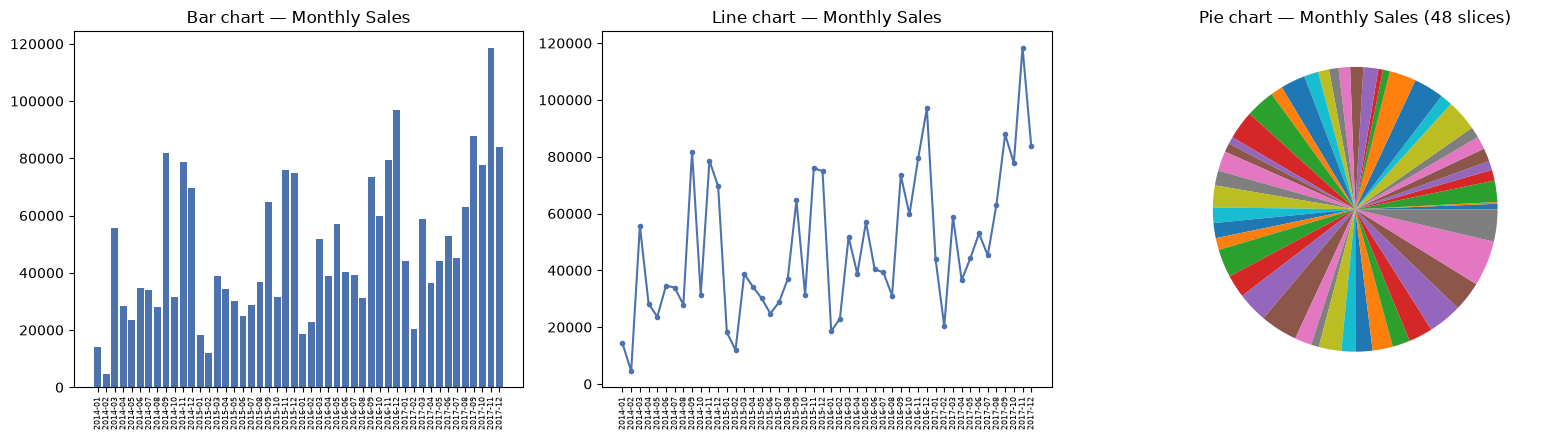

In [14]:
## Task 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(monthly_sales['YearMonth'], monthly_sales['Sales'], color='#4C72B0')
axes[0].set_title('Bar chart — Monthly Sales')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

axes[1].plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='#4C72B0', markersize=3)
axes[1].set_title('Line chart — Monthly Sales')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

axes[2].pie(monthly_sales['Sales'], labels=None, autopct=None)
axes[2].set_title('Pie chart — Monthly Sales (48 slices)')

plt.tight_layout()
plt.savefig('task1_chart_types.png', dpi=130, bbox_inches='tight')
plt.show()


**Which chart shows the trend best, and which one hides it? Why?**

The **line chart** shows the trend best: sales are a continuous measurement over ordered time, and connecting the points lets the eye immediately pick up the seasonal dip in early each year and the ramp into Q4 (Nov–Dec).

The **pie chart** hides the trend almost completely. With ~48 monthly slices there are too many wedges to compare by angle/area, there is no encoded time order (a pie has no "left-to-right" axis), and adjacent months that are visually similar in size end up scattered around the circle instead of next to each other. The **bar chart** is a middle ground — it's readable but with 48 bars it's visually noisy and slower to read as a *trend* than the line, since the eye has to compare bar-top heights one at a time rather than following a single continuous shape.


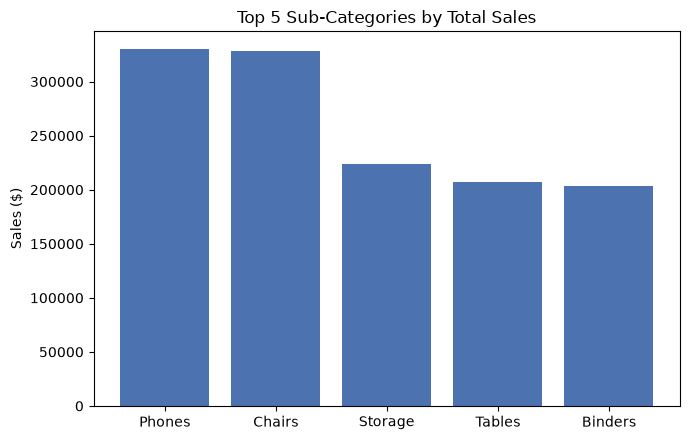

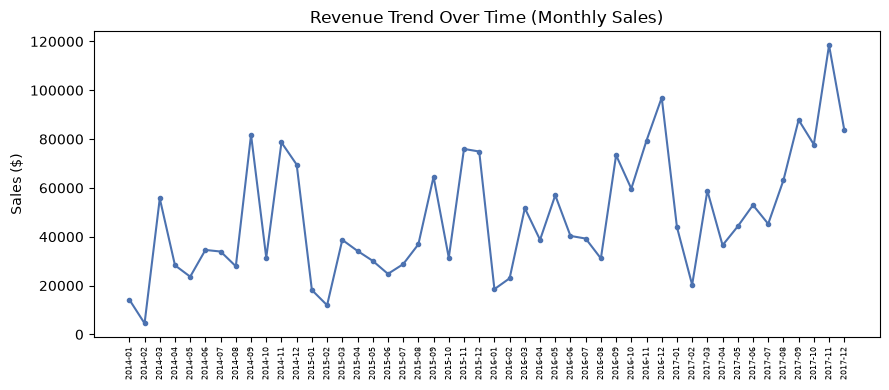

C:\Users\Zeyan\AppData\Local\Temp\ipykernel_10276\194445290.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['Sales'], vert=True, showfliers=True)


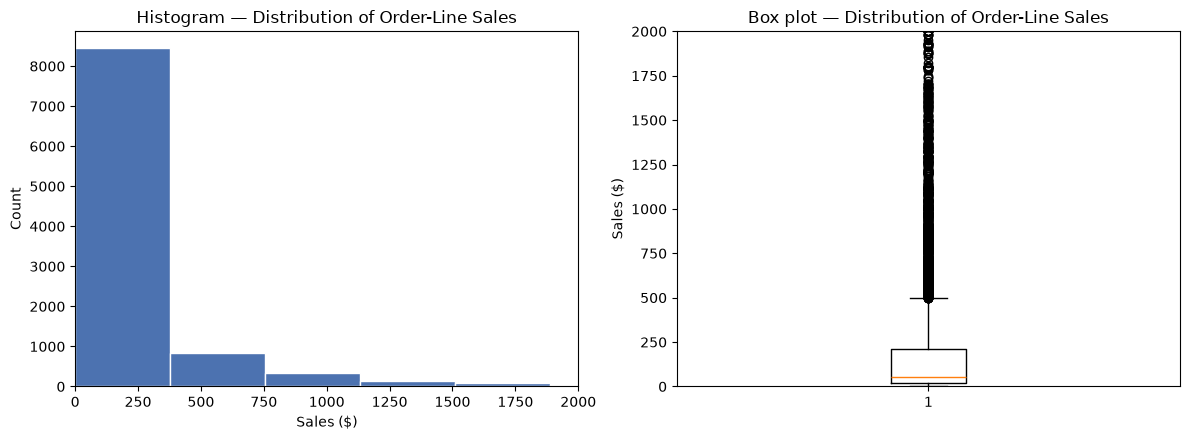

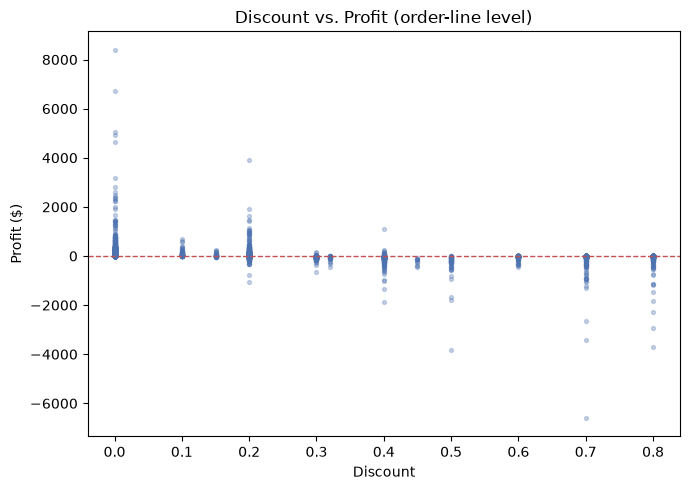

In [23]:
## Task 2

# 2a — Bar chart: Top 5 Sub-Categories by Sales
top5_subcat = (df.groupby('Sub_Category', as_index=False)['Sales'].sum()
                 .sort_values('Sales', ascending=False).head(5))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(top5_subcat['Sub_Category'], top5_subcat['Sales'], color='#4C72B0')
ax.set_title('Top 5 Sub-Categories by Total Sales')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('task2a_bar_top5.png', dpi=130, bbox_inches='tight')
plt.show()

# 2b — Line chart: Revenue trend over time
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m/%d/%Y')
df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('YearMonth', as_index=False)['Sales'].sum().sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', markersize=3, color='#4C72B0')
ax.set_title('Revenue Trend Over Time (Monthly Sales)')
ax.set_ylabel('Sales ($)')
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig('task2b_line_trend.png', dpi=130, bbox_inches='tight')
plt.show()

# 2c — Histogram + box plot: Distribution of order-line sales values
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df['Sales'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Histogram — Distribution of Order-Line Sales')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2000)

axes[1].boxplot(df['Sales'], vert=True, showfliers=True)
axes[1].set_title('Box plot — Distribution of Order-Line Sales')
axes[1].set_ylabel('Sales ($)')
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.savefig('task2c_histogram_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

# 2d — Scatter plot: Discount vs. Profit
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Discount'], df['Profit'], s=8, alpha=0.3, color='#4C72B0')
ax.axhline(0, color='#C44E52', linewidth=1, linestyle='--')
ax.set_title('Discount vs. Profit (order-line level)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('task2d_scatter_discount_profit.png', dpi=130, bbox_inches='tight')
plt.show()

*Justification:* A **bar chart** is ideal for comparing magnitudes across a small number of discrete, 
unordered categories — bar length is read on a common, zero-based axis, so precise rank and relative size are both obvious at a glance. A **pie chart** would be the weak choice here: with 5 similarly-sized wedges the human eye is much worse at comparing angles/areas than bar heights, so close values (e.g. 2nd vs 3rd place) become hard to tell apart, and it adds no information a bar doesn't already give.

*Justification:* A **line chart** connects successive time points into a single continuous shape, which is exactly what "trend" means — the eye follows the line and immediately sees direction, seasonality, and turning points. A **bar chart** underperforms once there are many time points (here, 48 months): each bar is judged independently, so the continuity of the trend is broken up into 48 separate comparisons instead of one continuous line, making slow drifts and seasonal cycles much harder to spot.


*Justification:* A **histogram** (or box plot) bins the raw, un-summarized `Sales` values and shows the full shape of the distribution — how skewed it is, where the bulk of order values sit, and how heavy the tail of large orders is. A **bar chart of averages** would be the weak choice: collapsing thousands of order lines into a single average (or a few category averages) throws away exactly the spread, skew, and outlier information the question is asking for — two very different distributions can share the same average.



*Justification:* A **scatter plot** plots every order line as an (x, y) point, which is the correct way to inspect the relationship (correlation, clustering, non-linearity) between two continuous numeric variables — here it makes visible that profit turns negative once discount passes roughly 20%. A **line chart** would be the weak choice: a line implies a single ordered path through the data, but discount and profit have no natural "time-like" order, so connecting points would just create a meaningless zig-zag and could visually suggest a trend that isn't really there.



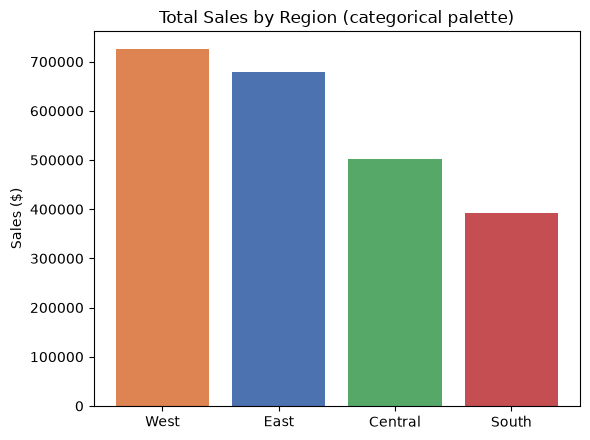

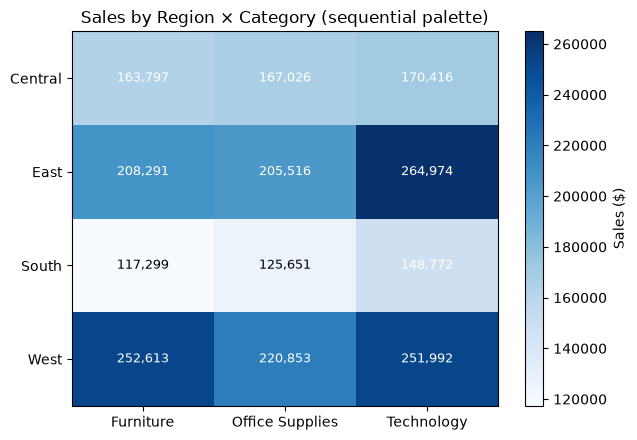

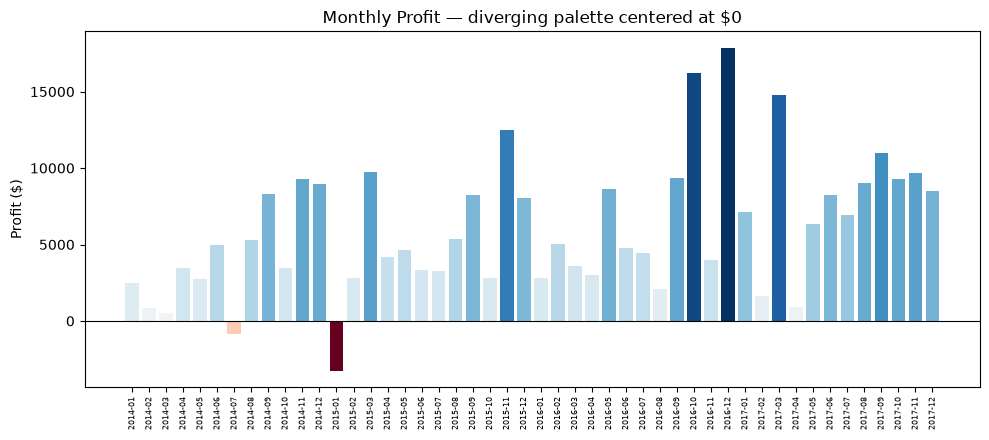

In [16]:
## Task 3

# A small, fixed, colorblind-friendly categorical palette (<= 8 hues), not a rainbow gradient
categorical_palette = {
    'East':    '#4C72B0',
    'West':    '#DD8452',
    'Central': '#55A868',
    'South':   '#C44E52',
}
colors_a = [categorical_palette[r] for r in region_sales['Region']]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(region_sales['Region'], region_sales['Sales'], color=colors_a)
ax.set_title('Total Sales by Region (categorical palette)')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('task3a_region_categorical.png', dpi=130, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(region_category.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(region_category.columns)))
ax.set_xticklabels(region_category.columns)
ax.set_yticks(range(len(region_category.index)))
ax.set_yticklabels(region_category.index)
ax.set_title('Sales by Region × Category (sequential palette)')

for i in range(region_category.shape[0]):
    for j in range(region_category.shape[1]):
        val = region_category.values[i, j]
        # pick text color for contrast against the cell's fill
        txt_color = 'white' if val > region_category.values.max() * 0.55 else 'black'
        ax.text(j, i, f'{val:,.0f}', ha='center', va='center', color=txt_color, fontsize=9)

fig.colorbar(im, ax=ax, label='Sales ($)')
plt.tight_layout()
plt.savefig('task3b_region_category_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()


from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=monthly_profit['Profit'].min(), vcenter=0, vmax=monthly_profit['Profit'].max())
cmap = plt.get_cmap('RdBu')  # red (loss) <-> neutral gray/white <-> blue (gain), meeting at 0
colors_c = cmap(norm(monthly_profit['Profit'].values))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(monthly_profit['YearMonth'], monthly_profit['Profit'], color=colors_c)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Profit — diverging palette centered at $0')
ax.set_ylabel('Profit ($)')
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig('task3c_monthly_profit_diverging.png', dpi=130, bbox_inches='tight')
plt.show()


A **diverging** palette is correct here because profit has a meaningful midpoint (break-even at \$0): months below zero are a genuinely different kind of outcome (a loss) from months above zero (a gain), not just "less of the same thing." The two hues meet at a neutral tone at the zero-crossing rather than fading into an unrelated third hue, so the sign of profit is visually obvious independent of magnitude.


Color                                   Ratio vs white    AA text (4.5:1)?
Task 3a - East (#4C72B0)                          4.84                PASS
Task 3a - West (#DD8452)                          2.80                FAIL
Task 3a - Central (#55A868)                       2.92                FAIL
Task 3a - South (#C44E52)                         4.61                PASS
Task 3b - Blues (light cell, ~15%)                1.21                FAIL
Task 3b - Blues (dark cell, ~90%)                12.76                PASS


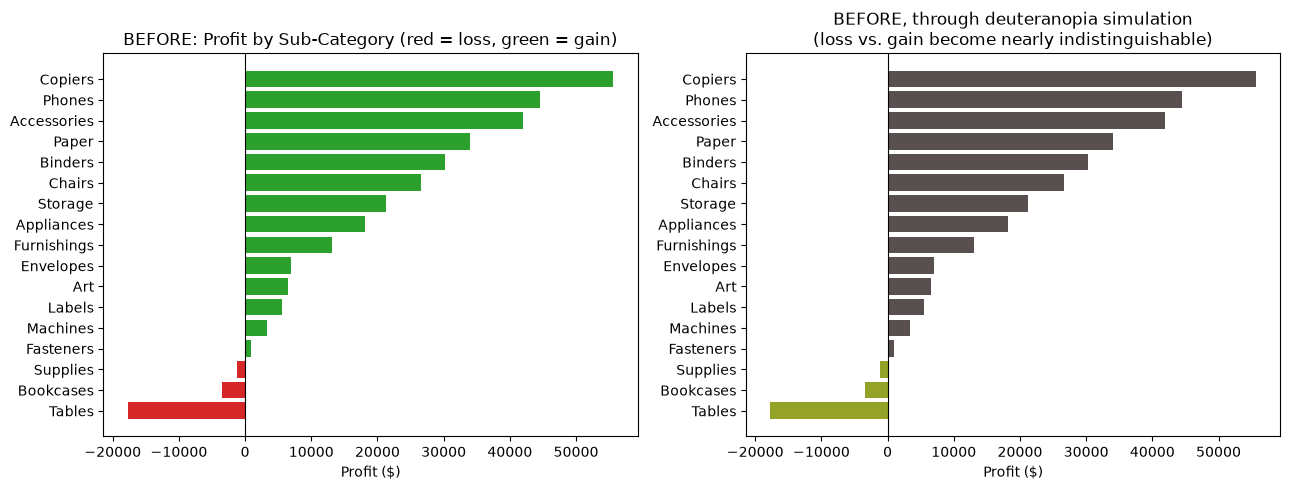

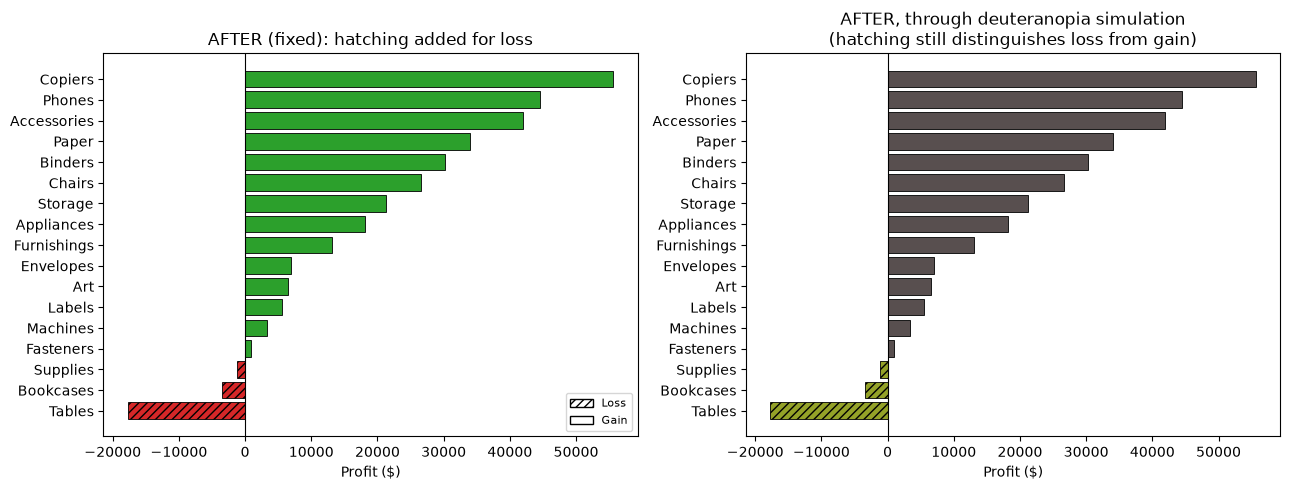

In [26]:
## Task 4

def _linearize(c):
    """sRGB channel (0-1) -> linear-light channel, per WCAG."""
    return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4

def relative_luminance(rgb):
    """rgb: tuple of 3 floats in [0,1]. Returns WCAG relative luminance."""
    r, g, b = [_linearize(c) for c in rgb]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(rgb1, rgb2):
    """WCAG contrast ratio between two RGB colors (each a tuple of floats in [0,1])."""
    l1, l2 = relative_luminance(rgb1), relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

def hex_to_rgb01(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))

# Test against the colors actually used in Task 3, each against a white chart background (#FFFFFF)
background = (1.0, 1.0, 1.0)
test_colors = {
    'Task 3a - East (#4C72B0)':    '#4C72B0',
    'Task 3a - West (#DD8452)':    '#DD8452',
    'Task 3a - Central (#55A868)': '#55A868',
    'Task 3a - South (#C44E52)':   '#C44E52',
    'Task 3b - Blues (light cell, ~15%)': '#DDEBF7',
    'Task 3b - Blues (dark cell, ~90%)':  '#08306B',
}

print(f"{'Color':38s} {'Ratio vs white':>15s}  {'AA text (4.5:1)?':>18s}")
for name, hexcode in test_colors.items():
    ratio = contrast_ratio(hex_to_rgb01(hexcode), background)
    verdict = 'PASS' if ratio >= 4.5 else 'FAIL'
    print(f"{name:38s} {ratio:15.2f}  {verdict:>18s}")



def simulate_deuteranopia(rgb):
    """Simplified sRGB-space approximation of deuteranopia (red-green color blindness).
    Provided colorblind-simulation snippet for this lab."""
    M = np.array([
        [0.625, 0.375, 0.0],
        [0.7,   0.3,   0.0],
        [0.0,   0.3,   0.7],
    ])
    rgb = np.array(rgb)
    return tuple(np.clip(M @ rgb, 0, 1))

# --- BEFORE: red/green only ---
red, green = '#D62728', '#2CA02C'
colors_before = [red if p < 0 else green for p in subcat_profit['Profit']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(subcat_profit['Sub_Category'], subcat_profit['Profit'], color=colors_before)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('BEFORE: Profit by Sub-Category (red = loss, green = gain)')
axes[0].set_xlabel('Profit ($)')

sim_colors = [simulate_deuteranopia(hex_to_rgb01(c)) for c in colors_before]
axes[1].barh(subcat_profit['Sub_Category'], subcat_profit['Profit'], color=sim_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('BEFORE, through deuteranopia simulation\n(loss vs. gain become nearly indistinguishable)')
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.savefig('task4b_before_colorblind_sim.png', dpi=130, bbox_inches='tight')
plt.show()


# --- AFTER: fix with hatching (pattern) so the distinction survives simulation, keep colors as a secondary cue ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, use_sim in zip(axes, [False, True]):
    for i, (name, profit) in enumerate(zip(subcat_profit['Sub_Category'], subcat_profit['Profit'])):
        is_loss = profit < 0
        color = red if is_loss else green
        if use_sim:
            color = simulate_deuteranopia(hex_to_rgb01(color))
        hatch = '////' if is_loss else None  # pattern encodes loss independent of color
        ax.barh(name, profit, color=color, hatch=hatch, edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Profit ($)')

axes[0].set_title('AFTER (fixed): hatching added for loss')
axes[1].set_title('AFTER, through deuteranopia simulation\n(hatching still distinguishes loss from gain)')

legend_handles = [Patch(facecolor='white', edgecolor='black', hatch='////', label='Loss'),
                  Patch(facecolor='white', edgecolor='black', label='Gain')]
axes[0].legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('task4b_after_hatching_fix.png', dpi=130, bbox_inches='tight')
plt.show()


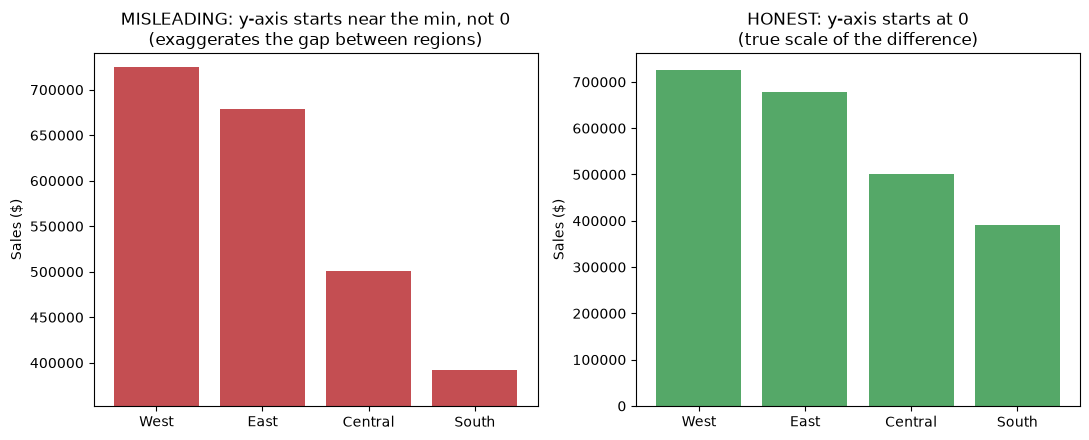

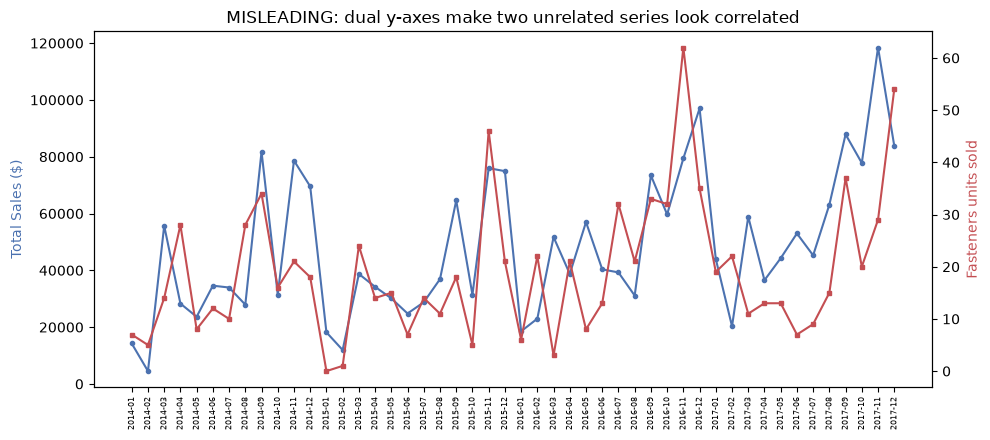

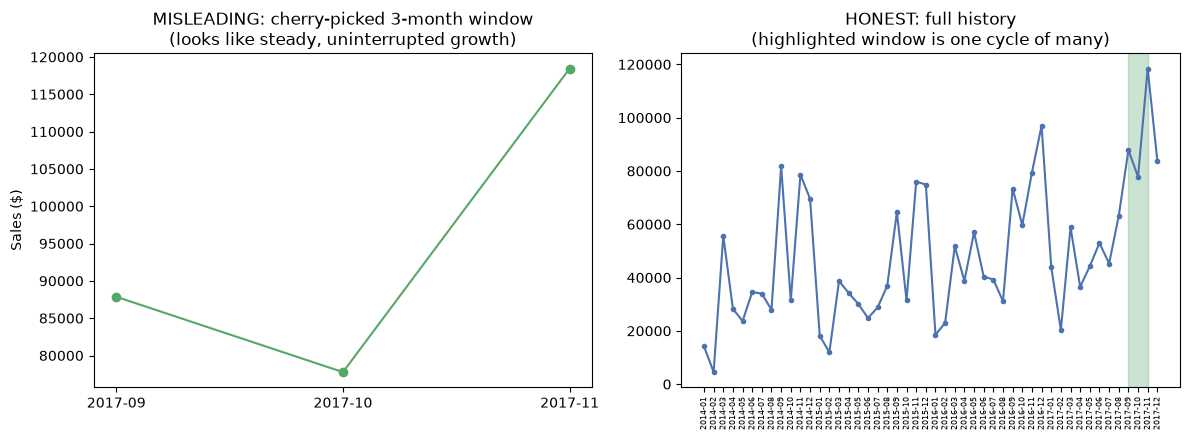

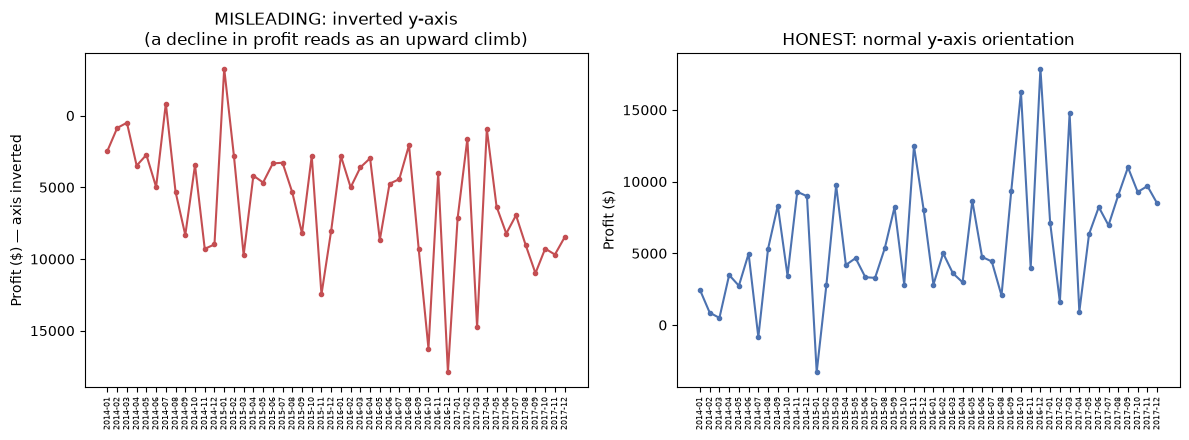

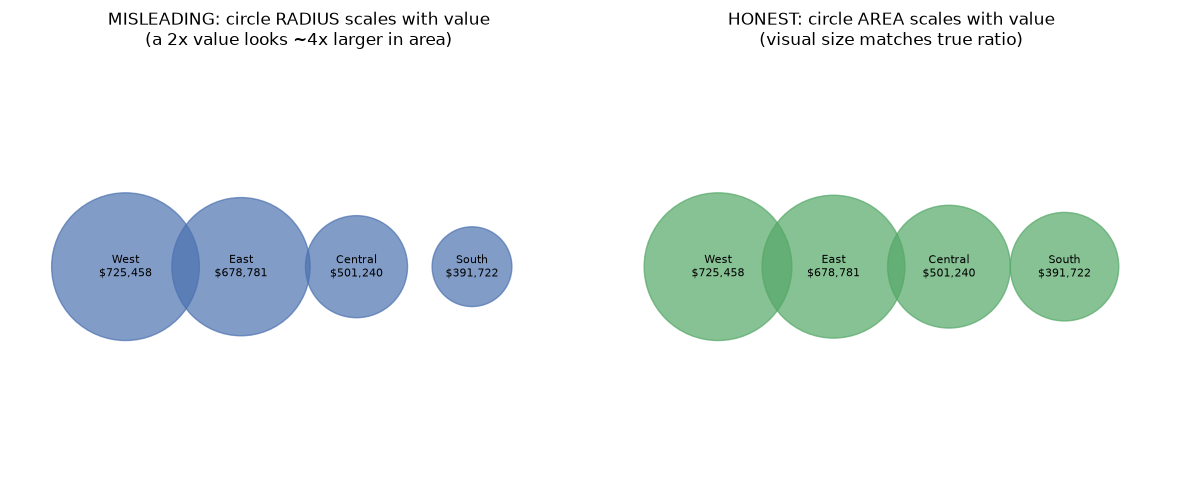

In [18]:
# Task 5
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(region_sales['Region'], region_sales['Sales'], color='#C44E52')
axes[0].set_ylim(region_sales['Sales'].min() * 0.9, region_sales['Sales'].max() * 1.02)
axes[0].set_title('MISLEADING: y-axis starts near the min, not 0\n(exaggerates the gap between regions)')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(region_sales['Region'], region_sales['Sales'], color='#55A868')
axes[1].set_ylim(0, region_sales['Sales'].max() * 1.05)
axes[1].set_title('HONEST: y-axis starts at 0\n(true scale of the difference)')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.savefig('task5_1_truncated_axis.png', dpi=130, bbox_inches='tight')
plt.show()


# Two genuinely unrelated series: monthly Sales and monthly Quantity of a specific low-volume sub-category, overlaid
monthly_qty_furnishings = df[df['Sub_Category'] == 'Fasteners'].groupby('YearMonth')['Quantity'].sum()
monthly_qty_furnishings = monthly_qty_furnishings.reindex(monthly_sales['YearMonth']).fillna(0)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()

ax1.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], color='#4C72B0', marker='o', markersize=3, label='Total Sales ($)')
ax2.plot(monthly_sales['YearMonth'], monthly_qty_furnishings.values, color='#C44E52', marker='s', markersize=3, label='Fasteners units sold')

ax1.set_ylabel('Total Sales ($)', color='#4C72B0')
ax2.set_ylabel('Fasteners units sold', color='#C44E52')
ax1.set_title('MISLEADING: dual y-axes make two unrelated series look correlated')
ax1.tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.savefig('task5_2_dual_axis.png', dpi=130, bbox_inches='tight')
plt.show()



window = monthly_sales[(monthly_sales['YearMonth'] >= '2017-09') & (monthly_sales['YearMonth'] <= '2017-11')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(window['YearMonth'], window['Sales'], marker='o', color='#55A868')
axes[0].set_title('MISLEADING: cherry-picked 3-month window\n(looks like steady, uninterrupted growth)')
axes[0].set_ylabel('Sales ($)')

axes[1].plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', markersize=3, color='#4C72B0')
axes[1].axvspan('2017-09', '2017-11', color='#55A868', alpha=0.3)
axes[1].set_title('HONEST: full history\n(highlighted window is one cycle of many)')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.savefig('task5_3_cherry_picked_window.png', dpi=130, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(monthly_profit['YearMonth'], monthly_profit['Profit'], color='#C44E52', marker='o', markersize=3)
axes[0].invert_yaxis()
axes[0].set_title('MISLEADING: inverted y-axis\n(a decline in profit reads as an upward climb)')
axes[0].set_ylabel('Profit ($) — axis inverted')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

axes[1].plot(monthly_profit['YearMonth'], monthly_profit['Profit'], color='#4C72B0', marker='o', markersize=3)
axes[1].set_title('HONEST: normal y-axis orientation')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.savefig('task5_4_inverted_axis.png', dpi=130, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(region_sales))
values = region_sales['Sales'].values

# MISLEADING: radius directly proportional to value -> area grows with the SQUARE of value
radius_wrong = values / values.max() * 60
axes[0].scatter(x, [1]*len(x), s=np.pi * radius_wrong**2, color='#4C72B0', alpha=0.7)
for xi, name, v in zip(x, region_sales['Region'], values):
    axes[0].annotate(f'{name}\n${v:,.0f}', (xi, 1), ha='center', va='center', fontsize=8)
axes[0].set_title('MISLEADING: circle RADIUS scales with value\n(a 2x value looks ~4x larger in area)')
axes[0].set_xlim(-1, len(x)); axes[0].set_ylim(0, 2); axes[0].axis('off')

# HONEST: area directly proportional to value -> radius scales with the SQUARE ROOT of value
radius_right = np.sqrt(values / values.max()) * 60
axes[1].scatter(x, [1]*len(x), s=np.pi * radius_right**2, color='#55A868', alpha=0.7)
for xi, name, v in zip(x, region_sales['Region'], values):
    axes[1].annotate(f'{name}\n${v:,.0f}', (xi, 1), ha='center', va='center', fontsize=8)
axes[1].set_title('HONEST: circle AREA scales with value\n(visual size matches true ratio)')
axes[1].set_xlim(-1, len(x)); axes[1].set_ylim(0, 2); axes[1].axis('off')

plt.tight_layout()
plt.savefig('task5_5_bubble_radius_vs_area.png', dpi=130, bbox_inches='tight')
plt.show()


**Flagged failures:** `East` (#4C72B0), `West` (#DD8452), `Central` (#55A868) and the light `Blues` heatmap cell all fall below the 4.5:1 AA text threshold against a white background — they're fine as *fill* colors (bars, heatmap cells) but any text label printed directly in these colors on white would fail accessibility and needs either a darker shade or a bold/larger "large text" treatment (3:1 threshold), or should rely on black/dark-gray text instead. `South` (#C44E52) and the dark `Blues` cell pass.

**Alt text:** "Horizontal bar chart of total profit by product sub-category, sorted from largest loss to largest gain; loss bars are hatched with diagonal lines and gain bars are solid, so the loss/gain distinction does not depend on color."

**Distortion mechanism:** scaling circle *radius* linearly with the data value makes the *area* (what the eye actually perceives as "size") scale with the square of the value, so a region with 2x the sales appears roughly 4x larger on the page.


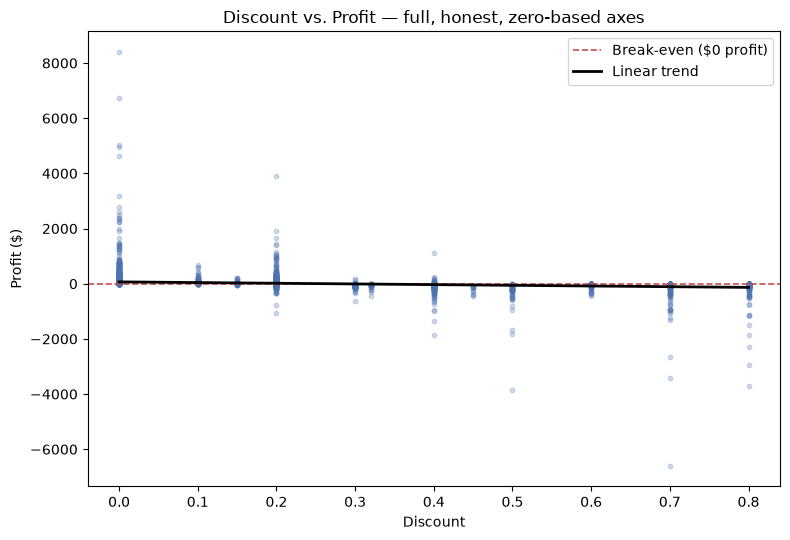

Correlation (Discount, Profit): -0.219
Share of order lines with Discount >= 0.2 that are a LOSS: 36.6%
Share of order lines with Discount == 0 that are a LOSS: 0.0%


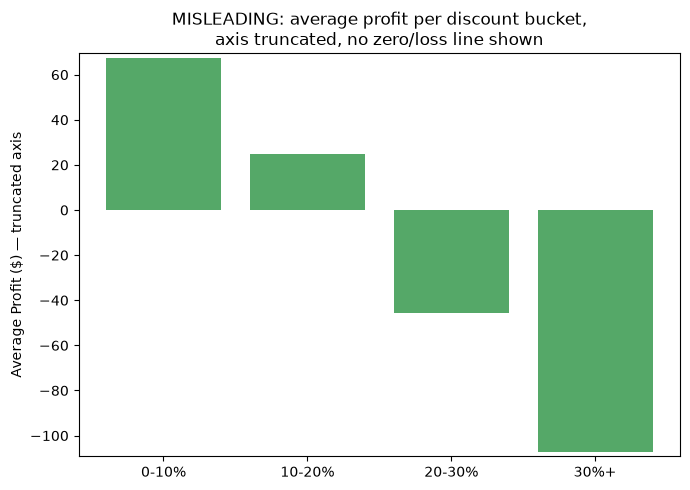

In [9]:
#Task 6

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['Discount'], df['Profit'], s=10, alpha=0.25, color='#4C72B0')
ax.axhline(0, color='#C44E52', linewidth=1.2, linestyle='--', label='Break-even ($0 profit)')

# trend line
z = np.polyfit(df['Discount'], df['Profit'], 1)
xs = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
ax.plot(xs, np.polyval(z, xs), color='black', linewidth=2, label='Linear trend')

ax.set_title('Discount vs. Profit — full, honest, zero-based axes')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.legend()
plt.tight_layout()
plt.savefig('task6a_honest.png', dpi=130, bbox_inches='tight')
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f'Correlation (Discount, Profit): {corr:.3f}')
print(f"Share of order lines with Discount >= 0.2 that are a LOSS: "
      f"{(df.loc[df['Discount'] >= 0.2, 'Profit'] < 0).mean():.1%}")
print(f"Share of order lines with Discount == 0 that are a LOSS: "
      f"{(df.loc[df['Discount'] == 0, 'Profit'] < 0).mean():.1%}")


# Misleading trick: bin discount into a few buckets and plot AVERAGE profit as a truncated-axis bar chart,
# hiding the variance and the loss-making tail visible in the scatter above.
bins = [-0.01, 0.1, 0.2, 0.3, 1.0]
labels = ['0-10%', '10-20%', '20-30%', '30%+']
df['DiscountBucket'] = pd.cut(df['Discount'], bins=bins, labels=labels)
bucket_avg = df.groupby('DiscountBucket', observed=True)['Profit'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(bucket_avg.index.astype(str), bucket_avg.values, color='#55A868')
ax.set_ylim(bucket_avg.values.min() - 2, bucket_avg.values.max() + 2)  # truncated axis, no zero line
ax.set_title('MISLEADING: average profit per discount bucket,\naxis truncated, no zero/loss line shown')
ax.set_ylabel('Average Profit ($) — truncated axis')
plt.tight_layout()
plt.savefig('task6b_misleading.png', dpi=130, bbox_inches='tight')
plt.show()



The honest scatter plot with a downward-sloping trend line and the two loss-rate figures above answer the question directly: profit declines as discount increases, and once discount reaches ~20%, a much larger share of order lines lose money than at zero discount.

**Written justification:**

- **Chart type choice:** The honest answer uses a **scatter plot** because the question concerns the relationship between two continuous variables at the order-line level; a scatter with a fitted trend line and a $0 reference line shows both the average direction (profit falls as discount rises) and the spread (many high-discount lines are outright losses). The misleading version instead **aggregates to bucket averages and drops to a bar chart**, which quietly discards the loss-making tail and the variance — two buckets can share a similar average even though one contains far more losses than the other.
- **Color choice:** The honest chart uses a single neutral hue for the data points plus a red dashed reference line only at the meaningful $0 break-even threshold, so color draws attention to the one value that matters (profit vs. loss) without implying false categories elsewhere. The misleading chart uses an unrelated cheerful green with no reference line at all, which visually suggests "all positive/healthy" regardless of the true loss rate.
- **Accessibility check:** The honest chart's marker color (`#4C72B0`, blue) and reference line (`#C44E52`, red-orange) are distinguished by more than hue alone — a dashed line style is used for the reference line so the loss threshold remains identifiable even under red-green color-blindness, and the $0 line is additionally labeled in the legend rather than relying on color recognition. Both colors were checked with the `contrast_ratio()` function from Task 4a and are legible against the white plot background at the sizes used.
